# VADEQ & StreamStats Model Evaluation

The purpose of this Jupyter notebook is to evaluate the selected model (Gradient Boosting Regressor) for the VADEQ and StreamStats dataset. This will evaluate model accuracy, XAI, and geographic visualizations.

Emma Reilly Oare

In [1]:
# Read in libs
import os
import warnings
import pandas as pd
import numpy as np 
import joblib
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer 
from sklearn.inspection import permutation_importance
import shap

# Suppress warnings
warnings.filterwarnings("ignore")

## Step 1. Import dataset

In [2]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [3]:
# Define paths
train_test_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "gbr_train_test_sets.pkl")
mdl_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "trained_gbr_model.pkl")

# Load train/test sets and model
x_train, x_test, y_train, y_test = joblib.load(train_test_path)
gbr_model = joblib.load(mdl_path)

## Step 2: Present metrics

In [4]:
# Read in metric dataframe
metric_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "vadeq_strmsts_models_metrics.xlsx")
metric_df = pd.read_excel(metric_path).drop(columns = 'Unnamed: 0')

In [5]:
# Display CV metrics for models
metric_df

,Model,CV RMSE,CV MAE,CV R2
0,GBR,12.538218,9.830621,0.693237
1,RF,12.639599,9.946764,0.688792
2,XGBoost,12.614185,9.945316,0.689147


## Step 3. Model Evaluation

### Step 3a. Model Predictions vs. Observed

In [6]:
# Create predictions
gbr_pred = gbr_model.predict(x_test)
y_test_np = y_test.to_numpy().reshape(-1)
gbr_residuals = y_test_np - gbr_pred.flatten()

# Display residual shape
gbr_residuals.shape

(224,)

In [7]:
# Print residual statistics for test set only
print("The maximum residual is", round(np.abs(gbr_residuals).max(), 4), "% embeddedness.")
print("The median residual is", round(np.median(np.abs(gbr_residuals)), 4), "% embeddedness.")
print("The minimum residual is", round(np.abs(gbr_residuals).min(), 4), "% embeddedness.")

The maximum residual is 46.3091 % embeddedness.
The median residual is 8.0666 % embeddedness.
The minimum residual is 0.1056 % embeddedness.


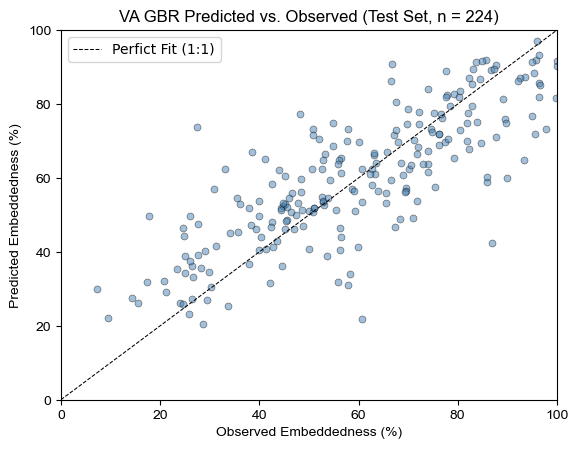

In [8]:
# Plot predictions vs observed
plt.scatter(y_test,
            gbr_pred,
            color = 'steelblue',
            alpha = 0.5,
            s = 25,
            edgecolors = 'black',
            linewidths = 0.5)
plt.xlabel('Observed Embeddedness (%)', fontname = 'Arial')
plt.ylabel('Predicted Embeddedness (%)', fontname = 'Arial')
plt.title('VA GBR Predicted vs. Observed (Test Set, n = 224)', fontname = 'Arial')
plt.ylim([0, 100])
plt.xlim([0, 100])
plt.plot([0, 100], [0, 100],
         color = 'k',
         linestyle = '--',
         linewidth = 0.75,
        label = 'Perfict Fit (1:1)')
plt.legend()
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")

# Save to results folder
predict_obs_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "gbr_predict_vs_obs_testset.png")
plt.savefig(predict_obs_path, dpi = 300)

# Show plot
plt.show()

### Step 3b. Residual scatter plot

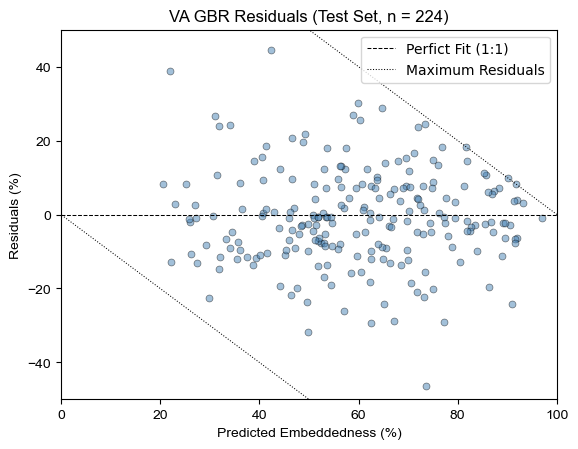

In [9]:
# Plot residuals
plt.scatter(gbr_pred,
            gbr_residuals,
            color = 'steelblue',
            s = 25,
            alpha = 0.5,
            edgecolors = 'black',
            linewidths = 0.5)
plt.xlabel('Predicted Embeddedness (%)', fontname = 'Arial')
plt.ylabel('Residuals (%)', fontname = 'Arial')
plt.title('VA GBR Residuals (Test Set, n = 224)', fontname = 'Arial')
plt.ylim([-50, 50])
plt.xlim([0, 100])

# Plot perfect prediction line
plt.axhline(y = 0,
            color = 'k',
            linestyle = '--',
           linewidth = 0.75,
           label = 'Perfict Fit (1:1)')

# Plot boundaries
plt.plot([100, 0], [0, 100],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75,
        label = 'Maximum Residuals')
plt.plot([100, 0], [-100, 0],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
plt.legend()

# Save to results folder
resid_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "gbr_residuals_testset.png")
plt.savefig(resid_path, dpi = 300)

# Show plot
plt.show()

### Step 3c. Plot residual histogram
We want to ensure we are having normally distributed residuals from the model.

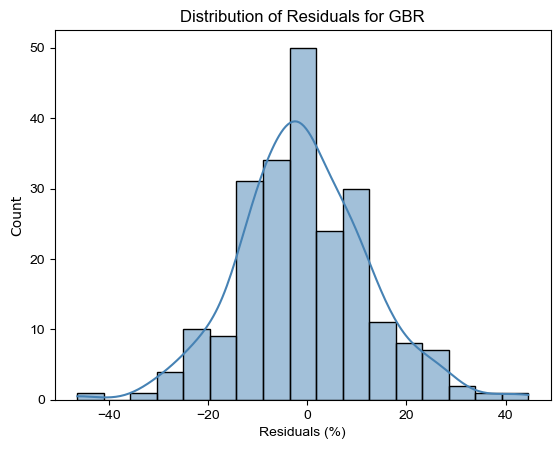

In [10]:
# Plot residuals distribution to check for Gaussian distribution
sns.histplot(gbr_residuals, kde=True, color = 'steelblue', alpha = 0.5)
plt.xlabel('Residuals (%)', fontname = 'Arial')
plt.title('Distribution of Residuals for GBR', fontname = 'Arial')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")

# Save to results folder
resid_hist_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "gbr_residual_hist.png")
plt.savefig(resid_hist_path, dpi = 300)

# Show plot
plt.show()

## Step 4. Explainability

### Step 4a. Feature Importance

In [26]:
# Calculate impurity-based importances
importances = gbr_model.feature_importances_
indices = np.argsort(importances)[::-1] 
feature_names = x_test.columns

# Display importances
importances

array([0.19743406, 0.16336001, 0.12630977, 0.03714049, 0.10087381,
       0.03511463, 0.01047272, 0.06393982, 0.05064989, 0.04617676,
       0.04322574, 0.02799282, 0.03553139, 0.02357753, 0.00446349,
       0.00630802, 0.02351548, 0.00391357])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


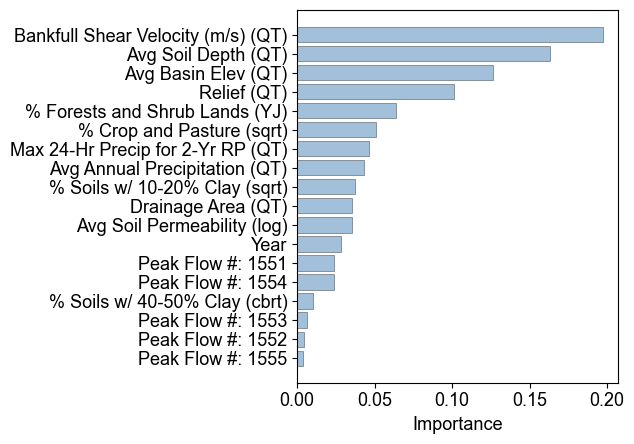

In [31]:
# plt.title("Impurity-Based Feature Importances", fontname = 'Arial')
plt.figure(figsize=(6, 4.5))
plt.barh(range(len(importances)), 
        importances[indices], 
        align='center', 
        color = 'steelblue',
        edgecolor = 'black',
         alpha = 0.5,
        linewidth = 0.5)
plt.gca().invert_yaxis() # flip y-axis
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel("Importance", fontname = 'Arial', fontsize=13)
plt.tight_layout()
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
    tick.set_fontsize(13)
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
    tick.set_fontsize(13)

# Save to results folder
feat_imp_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "gbr_impurity_feature_importances.png")
plt.savefig(feat_imp_path, dpi = 300, bbox_inches = 'tight')

# Plot bar plots
plt.show()

#### Permutation Importance
Permutaton importance measures the increase in predicted error of the model after we permuted the feature's values. Permuting is the rearrangement of features. We measure the importance of a feature by calculating the increase in the model's prediction error after shuffling. A feature is “important” if shuffling its values increases the model error, because in this case the model relied on the feature for the prediction.

<br> Explanation from https://christophm.github.io/interpretable-ml-book/feature-importance.html

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


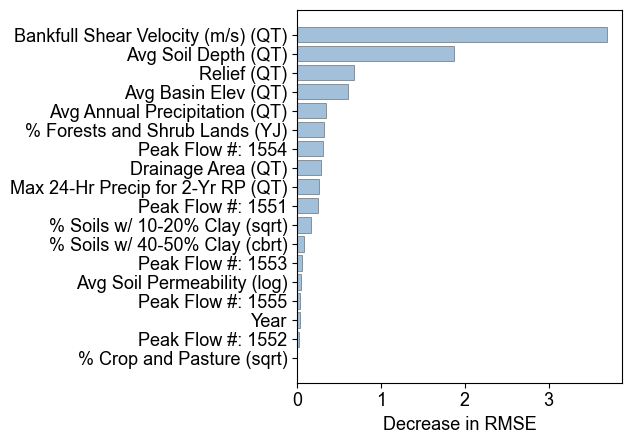

In [24]:
# Calculate permutation importances 
rmse_scorer = make_scorer(lambda y_true, gbr_pred: -np.sqrt(mean_squared_error(y_true, gbr_pred)))
result = permutation_importance(gbr_model, x_test, y_test, 
                                scoring=rmse_scorer, 
                                random_state = 42, 
                                n_repeats = 20)

# Create df for results
perm_importance_df = pd.DataFrame({'Feature': x_test.columns.values.tolist(),
                                'Importance': result.importances_mean,
                                'Std': result.importances_std}).sort_values(by='Importance', ascending=True)

# Plot figure
plt.figure(figsize=(6, 4.5))
plt.barh(perm_importance_df['Feature'], 
         perm_importance_df['Importance'], 
         color = 'steelblue',
         alpha = 0.5,
        edgecolor = 'k',
        linewidth =  0.5)
plt.xlabel('Decrease in RMSE', fontname = 'Arial', fontsize=13)
# plt.title('Permutation Feature Importance', fontname = 'Arial')
plt.tight_layout()
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
    tick.set_fontsize(13)
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
    tick.set_fontsize(13)

# Save figure to results folder
perm_imp_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "gbr_permutation_importances.png")
plt.savefig(perm_imp_path, dpi = 300, bbox_inches = 'tight')

# Show figure
plt.show()

### Step 4b. Global SHAP plots

In [32]:
# Initialize the SHAP explainer
explainer = shap.TreeExplainer(gbr_model)
shap_values = explainer.shap_values(x_test)

#### Summary Plot (Bar)
The summary plot offers a comprehensive view of the most influential features in a model. It **ranks** features based on their effect on the model's predictions. The bar plot specifically presents each feature's average absolute SHAP values.

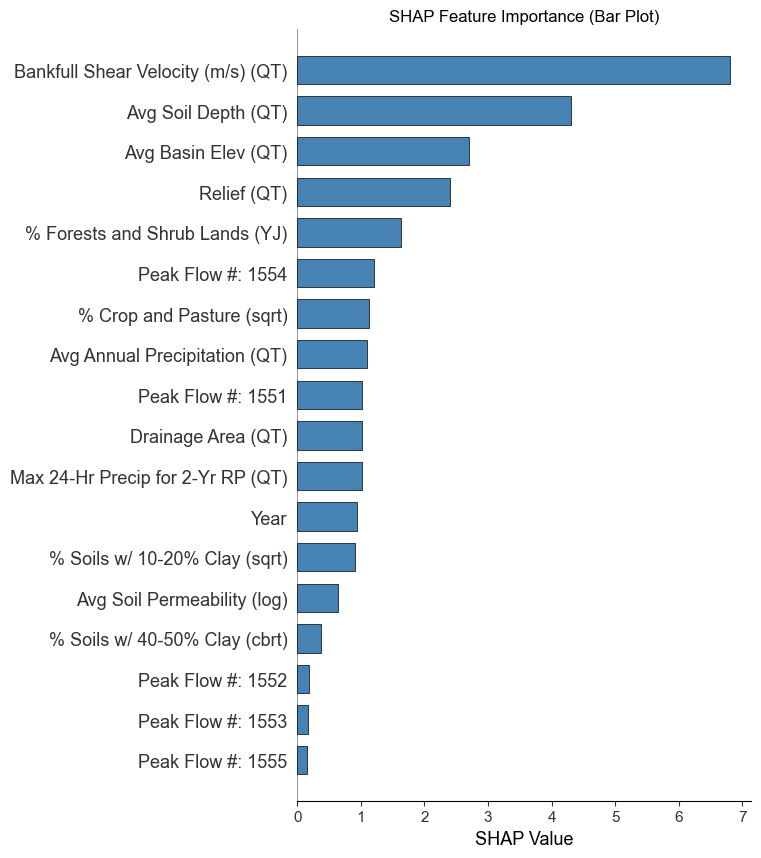

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\reill\\Documents\\Virginia Tech\\Czuba Research\\Embeddedness\\GitHub\\Embeddedness_ML_XAI\\models\\model1_streamstats_va\\results\\figures\\shap_summary_bar.png'

<Figure size 640x480 with 0 Axes>

In [28]:
# SHAP Summary Plot (Bar)
plt.title("SHAP Feature Importance (Bar Plot)", fontname = 'Arial')
shap.summary_plot(shap_values, x_test, 
                  plot_type = "bar", 
                  show = False,
                  color = 'steelblue',
                 alpha = 0.5)
plt.xlabel('SHAP Value', fontname = 'Arial')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for patch in ax.patches:
    patch.set_edgecolor('k')
    patch.set_linewidth(0.5)
plt.show()

# Save to results folder
shap_bar_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_summary_bar.png")
plt.savefig(shap_bar_path, dpi = 600, bbox_inches = 'tight')

# Show plot
plt.show()

#### Summary Plot (Dot)
The dot summary plot is similar to the bar, but each dot represents a specific prediction. The feature value relates directly to the features actual numerical value, while it's location on the x-axis denotes its effect on the model prediction.

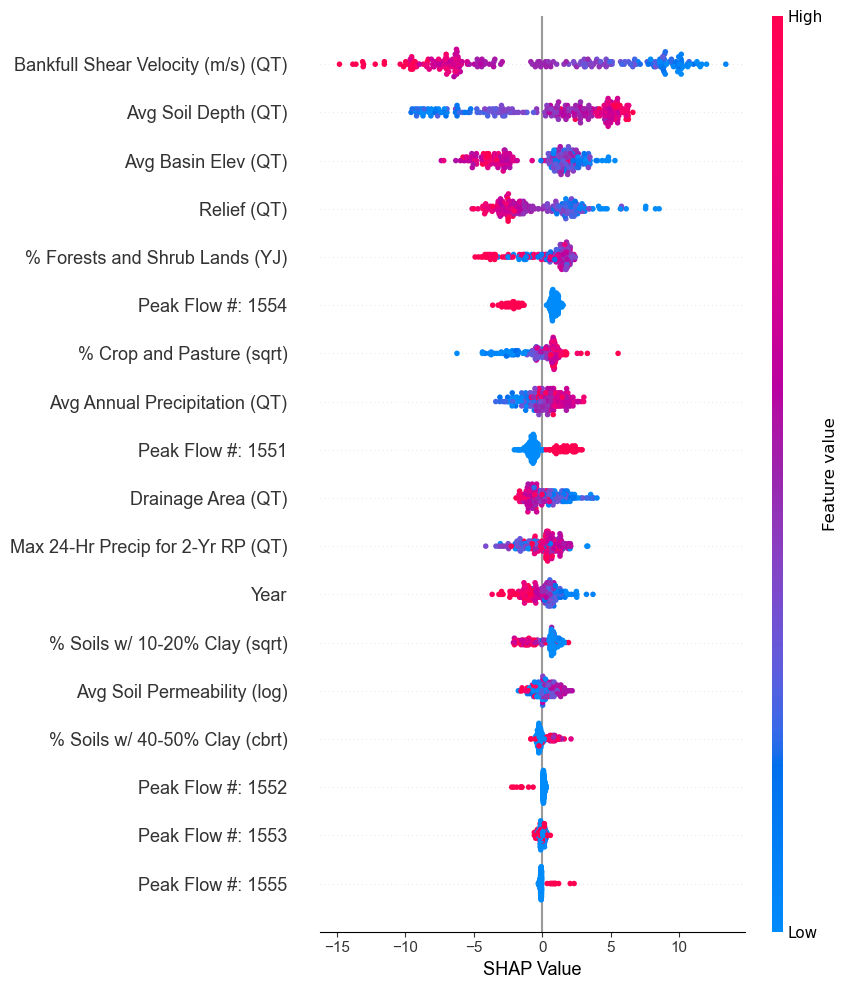

In [33]:
# SHAP Summary Plot Dot
shap.summary_plot(shap_values, x_test, 
                  show = False,
                 plot_size=(9, 10))
plt.xlabel('SHAP Value', fontname = 'Arial')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
    
# Save to results folder
shap_dot_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "shap_summary_dot.eps")
plt.savefig(shap_dot_path, dpi = 300, bbox_inches = 'tight', format='eps')

# Show plot
plt.show()

#### Dependence Plots
We'll look at the top five features and use a dependence plot. These are still global (for the full test set).

In [ ]:
# Shows comparison to soil depth
shap.dependence_plot('Bankfull Shear Velocity (m/s) (QT)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'steelblue',
                     alpha = 0.5,
                    show = False)

plt.scatter(plt.gca().collections[0].get_offsets()[:, 0],
            plt.gca().collections[0].get_offsets()[:, 1],
            edgecolors='k',
            linewidths=0.5,
            alpha = 0.5,
            s = 25,
            color='steelblue')
    
# Save to results folder
shap_soil_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_ustar_dependence.png")
plt.savefig(shap_soil_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Shows comparison to soil depth
shap.dependence_plot('Avg Soil Depth (QT)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'steelblue',
                    show = False)

plt.scatter(plt.gca().collections[0].get_offsets()[:, 0],
            plt.gca().collections[0].get_offsets()[:, 1],
            edgecolors='k',
            linewidths=0.5,
            alpha = 0.5,
            s = 25,
            color='steelblue')

# Save to results folder
shap_soil_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_soil_dependence.png")
plt.savefig(shap_soil_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Shows comparison to elevation
shap.dependence_plot('Avg Basin Elev (QT)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'steelblue',
                    show = False)

plt.scatter(plt.gca().collections[0].get_offsets()[:, 0],
            plt.gca().collections[0].get_offsets()[:, 1],
            edgecolors='k',
            linewidths=0.5,
            alpha = 0.5,
            s = 25,
            color='steelblue')

# Save to results folder
shap_elev_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_elev_dependence.png")
plt.savefig(shap_elev_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Shows comparison to forest/shrub
shap.dependence_plot('% Forests and Shrub Lands (YJ)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'k',
                    show = False)

# Save to results folder
shap_forest_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_forest_dependence.png")
plt.savefig(shap_forest_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Shows comparison to relief
shap.dependence_plot('Relief (QT)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'k',
                    show = False)

# Save to results folder
shap_relief_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_relief_dependence.png")
plt.savefig(shap_relief_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# List your 3 feature names
features = [
    'Bankfull Shear Velocity (m/s) (QT)',
    'Avg Soil Depth (QT)',
    '% Forests and Shrub Lands (YJ)'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, feature in enumerate(features):
    ax = axes[i]
    shap_vals = shap_values[:, x_test.columns.get_loc(feature)]
    x_vals = x_test[feature]
    ax.scatter(x_vals, shap_vals, alpha=0.5, edgecolors='k', linewidths=0.5, color='steelblue')
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel('Feature Value')
    if i == 0:
        ax.set_ylabel('SHAP Value')
    plt.tight_layout()

# Save to results folder
shap_depend_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_tri_dependence.png")
plt.savefig(shap_depend_path, dpi = 600, bbox_inches = 'tight')

plt.tight_layout()
plt.show()

### Step 4c. Local SHAP Plots
The local SHAP plots are for looking at specific predictions in the test set. We're going to look at:
- Two maximum positive residuals
- Two maximum negative residuals
- Two lowest residuals

In [ ]:
# Create dataframe of predicted, true, and residuals
results_df = pd.DataFrame({'True': y_test_np,
                           'Predicted': gbr_pred,
                           'Residual': gbr_residuals})

# Display dataframe
results_df

In [ ]:
# Sort to find key cases
max_positive_residual = results_df.nlargest(2, 'Residual')
max_negative_residual = results_df.nsmallest(2, 'Residual')
lowest_residuals = results_df.iloc[(results_df['Residual'] - 0).abs().argsort()[:2]]  # Most accurate predictions

# Combine all selected instances
selected_instances = pd.concat([max_positive_residual, max_negative_residual, lowest_residuals])

# Print results
selected_instances

#### Force Plots
The SHAP force plots explain the deviation from an expected value by showing how each feature pushes the prediction up or down. The *expected_value* is the average model prediction. The *f(x)* is the final predicted value for the given instance.

In [ ]:
# Define index being used
index = selected_instances.iloc[0].name
# Initialize javascript lib
shap.initjs()

# Plot force plot
shap.plots.force(explainer.expected_value, 
                 shap_values[index], 
                 x_test.iloc[index],
                text_rotation = 90)

In [ ]:
# Print information on sample above
print(f"Force Plot for instance where True Value = {(selected_instances.iloc[0, 0]):.2f}, Predicted Value = {selected_instances.iloc[0, 1]:.2f}, and Residual = {selected_instances.iloc[0, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[1].name

# Plot force plot
shap.plots.force(explainer.expected_value, 
                 shap_values[index], 
                 x_test.iloc[index],
                text_rotation = 90)

In [ ]:
# Print information on sample above
print(f"Force Plot for instance where True Value = {(selected_instances.iloc[1, 0]):.2f}, Predicted Value = {selected_instances.iloc[1, 1]:.2f}, and Residual = {selected_instances.iloc[1, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[2].name

# Plot force plot
shap.plots.force(explainer.expected_value, 
                 shap_values[index], 
                 x_test.iloc[index],
                text_rotation = 90)

In [ ]:
# Print information on sample above
print(f"Force Plot for instance where True Value = {(selected_instances.iloc[2, 0]):.2f}, Predicted Value = {selected_instances.iloc[2, 1]:.2f}, and Residual = {selected_instances.iloc[2, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[3].name

# Plot force plot
shap.plots.force(explainer.expected_value, 
                 shap_values[index], 
                 x_test.iloc[index],
                text_rotation = 90)

In [ ]:
# Print information on sample above
print(f"Force Plot for instance where True Value = {(selected_instances.iloc[3, 0]):.2f}, Predicted Value = {selected_instances.iloc[3, 1]:.2f}, and Residual = {selected_instances.iloc[3, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[4].name

# Plot force plot
shap.plots.force(explainer.expected_value, 
                 shap_values[index], 
                 x_test.iloc[index],
                text_rotation = 90)

In [ ]:
# Print information on sample above
print(f"Force Plot for instance where True Value = {(selected_instances.iloc[4, 0]):.2f}, Predicted Value = {selected_instances.iloc[4, 1]:.2f}, and Residual = {selected_instances.iloc[4, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[5].name

# Plot force plot
shap.plots.force(explainer.expected_value, 
                 shap_values[index], 
                 x_test.iloc[index],
                text_rotation = 90)

In [ ]:
# Print information on sample above
print(f"Force Plot for instance where True Value = {(selected_instances.iloc[5, 0]):.2f}, Predicted Value = {selected_instances.iloc[5, 1]:.2f}, and Residual = {selected_instances.iloc[5, 2]:.2f}")

#### Decision Plots
Decision Plots will show the same thing as force plots, but in a different format. This can be easier to visualize in some cases. The variables described above are the same.

In [ ]:
# Define index being used
index = selected_instances.iloc[0].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_max_pos_1_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_decision_max_pos_1.png")
plt.savefig(shap_max_pos_1_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Print information on sample above
print(f"Decision Plot for instance where True Value = {(selected_instances.iloc[0, 0]):.2f}, Predicted Value = {selected_instances.iloc[0, 1]:.2f}, and Residual = {selected_instances.iloc[0, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[1].name


# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_max_pos_2_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_decision_max_pos_2.png")
plt.savefig(shap_max_pos_2_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Print information on sample above
print(f"Decision Plot for instance where True Value = {(selected_instances.iloc[1, 0]):.2f}, Predicted Value = {selected_instances.iloc[1, 1]:.2f}, and Residual = {selected_instances.iloc[1, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[2].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_max_neg_1_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_decision_max_neg_1.png")
plt.savefig(shap_max_neg_1_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Print information on sample above
print(f"Decision Plot for instance where True Value = {(selected_instances.iloc[2, 0]):.2f}, Predicted Value = {selected_instances.iloc[2, 1]:.2f}, and Residual = {selected_instances.iloc[2, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[3].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_max_neg_2_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_decision_max_neg_2.png")
plt.savefig(shap_max_neg_2_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Print information on sample above
print(f"Decision Plot for instance where True Value = {(selected_instances.iloc[3, 0]):.2f}, Predicted Value = {selected_instances.iloc[3, 1]:.2f}, and Residual = {selected_instances.iloc[3, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[4].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_min_resid1_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_decision_min_resid1.png")
plt.savefig(shap_min_resid1_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Print information on sample above
print(f"Decision Plot for instance where True Value = {(selected_instances.iloc[4, 0]):.2f}, Predicted Value = {selected_instances.iloc[4, 1]:.2f}, and Residual = {selected_instances.iloc[4, 2]:.2f}")

In [ ]:
# Define index being used
index = selected_instances.iloc[5].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_min_resid2_path = os.path.join(BASE_DIR, "models", "model1_streamstats_va", "results", "figures", "shap_decision_min_resid2.png")
plt.savefig(shap_min_resid2_path, dpi = 600, bbox_inches = 'tight')

# Show plow
plt.show()

In [ ]:
# Print information on sample above
print(f"Decision Plot for instance where True Value = {(selected_instances.iloc[5, 0]):.2f}, Predicted Value = {selected_instances.iloc[5, 1]:.2f}, and Residual = {selected_instances.iloc[5, 2]:.2f}")

### Step 4d. Geographic Results
We'll plot the results from the testset in a couple ways.

In [ ]:
# Read in coordinates
coords_path = os.path.join(BASE_DIR, "data", "GIS", "vadeq_sites_albers.xlsx")
coords = pd.read_excel(coords_path)

# Print coords
coords

In [ ]:
# Create dataframe for map plotting from test set
map_testset_df = pd.DataFrame(y_test)
map_testset_df['Prediction'] = gbr_pred
map_testset_df['Residual'] = gbr_residuals
map_testset_df['Residual_Abs'] = map_testset_df['Residual'].abs()

# Print dataframe
map_testset_df

In [ ]:
# Read in vadeq_strmstats dataset to align index to StationID
vadeq_strmstats_path = os.path.join(BASE_DIR, "data", "processed", "virginia", "vadeq_strmsts_after_eda.xlsx")
vadeq_strmstats = pd.read_excel(vadeq_strmstats_path).drop(columns = 'Unnamed: 0')

# Display df
vadeq_strmstats

In [ ]:
# Join testset results to original vadeq df
vadeq_testset = map_testset_df.merge(vadeq_strmstats,
                                     left_index = True,
                                     right_index = True,
                                     how = 'left')

# Display dataframe
vadeq_testset

In [ ]:
# Join coordinates with test set results
vadeq_testset_map = vadeq_testset.merge(coords,
                                       on = ['StationID', 'LATITUDE', 'LONGITUDE'],
                                       how = 'left')

# Display results of merging
vadeq_testset_map.describe()

In [ ]:
# Create text column for map label
vadeq_testset_map['text'] = 'Station ID ' + vadeq_testset_map['StationID'] + ', ' + 'Actual: ' + vadeq_testset_map['Streambed Embeddedness (%)'].astype(int).astype(str) + '%' + ', ' + 'Prediction: ' + vadeq_testset_map['Prediction'].astype(int).astype(str) + '%'

# Display new text column
vadeq_testset_map[['text']]

##### Export geographic results dataset
Location of map: https://arcg.is/1nXqzK1

In [ ]:
# Export to csv
map_path = os.path.join(BASE_DIR, 'data', 'GIS', 'vadeq_map_testset.csv')
vadeq_testset_map.to_csv(map_path)

In [ ]:
# Import dependencies bc Dash is dramatic
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.graph_objects as go

# Create the Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    dcc.Graph(id='geo-scatter'),
    dcc.RangeSlider(
        id='year-slider',
        min=vadeq_testset_map['Year'].min(),
        max=vadeq_testset_map['Year'].max(),
        value=[vadeq_testset_map['Year'].min(), vadeq_testset_map['Year'].max()],
        marks={str(year): str(year) for year in vadeq_testset_map['Year'].unique()},
        step=None
    )
])

@app.callback(
    Output('geo-scatter', 'figure'),
    [Input('year-slider', 'value')]
)
def update_figure(selected_years):
    filtered_df = vadeq_testset_map[
        (vadeq_testset_map['Year'] >= selected_years[0]) &
        (vadeq_testset_map['Year'] <= selected_years[1])
    ]

    fig = go.Figure(data=go.Scattergeo(
        locationmode='USA-states',
        lon=filtered_df['LONGITUDE'],
        lat=filtered_df['LATITUDE'],
        text=filtered_df['text'],
        mode='markers',
        marker=dict(
            size=8,
            opacity=0.8,
            reversescale=True,
            symbol='circle',
            line=dict(
                width=1,
                color='rgba(102, 102, 102)'
            ),
            colorscale='spectral',
            cmin=filtered_df['Residual'].min(),
            color=filtered_df['Residual'],
            cmax=filtered_df['Residual'].max(),
            colorbar_title="Model Residuals<br>in % Embeddedness"
        )
    ))

    fig.update_geos(fitbounds='locations')
    fig.update_layout(
        title='Actual vs. Predicted Embeddedness<br>(Hover for Station ID)',
        geo=dict(
            scope='usa',
            showsubunits=True,
            projection_type='albers usa',
            showland=True,
            landcolor="rgb(250, 250, 250)",
            subunitcolor="Black",
            countrycolor="rgb(217, 217, 217)",
            countrywidth=0.5,
            subunitwidth=0.5
        ),
    )
    return fig

if __name__ == '__main__':
    app.run_server(debug=True, port = 8051)

### Step 4e. Reference Site Comparison
The VA DEQ was able to provide a categorical value for each site indicating its reference status. These were merged with the testset to analyze if clear clustering occurs.

In [ ]:
# Import reference site datasets
upland_path = os.path.join(BASE_DIR, 'data', 'raw', 'virginia', 'GenusMMI_Raw_Uplands_Data.xlsx')
coast_path = os.path.join(BASE_DIR, 'data', 'raw', 'virginia', 'GenusMMI_Raw_Coast_Data.xlsx')
upland_ref = pd.read_excel(upland_path)
coast_ref = pd.read_excel(coast_path)

# Select for only reference status (this is all we need for plotting right now)
upland_ref = upland_ref[['StationID', 'RefStress']]
coast_ref = coast_ref[['StationID', 'RefStress']]

In [ ]:
# Select for only unique pairs (hopefully this works first try)
unique_upland_ref = upland_ref.drop_duplicates(subset=['StationID', 'RefStress'])
unique_coast_ref = coast_ref.drop_duplicates(subset = ['StationID', 'RefStress'])

In [ ]:
# Display statistics of upland reference
unique_upland_ref.describe()

In [ ]:
# Display statistics of coast reference
unique_coast_ref.describe()

In [ ]:
# Join reference site information to the original dataset
join1 = vadeq_testset.merge(unique_upland_ref,
                           on = 'StationID',
                           how = "left")
join1[['RefStress']].describe()

In [ ]:
# Join reference site information to the original dataset
join2 = vadeq_testset.merge(unique_coast_ref,
                                on = 'StationID',
                               how = "left")
join2[['RefStress']].describe()

In [ ]:
# Concatenate two datasets into full testset dataset
vadeq_testset_refs = pd.concat([join1, join2])
vadeq_testset_refs[['RefStress']].describe()

In [ ]:
vadeq_testset_refs['RefStress'] = vadeq_testset_refs['RefStress'].astype('category')
# Rename categores
vadeq_testset_refs['RefStress'] = vadeq_testset_refs['RefStress'].cat.rename_categories({'Str':'Stressed',
                                                            'Int':'Intermediate',
                                                            'Ref':'Reference'})

In [ ]:
vadeq_testset_refs

In [ ]:
# Create same scatterplot of residuals with categorical color-coding based on reference site information
sns.scatterplot(data=vadeq_testset_refs, x ='Prediction', 
                y = 'Residual', 
                hue='RefStress', 
                s = 25,
                palette={'Stressed': 'r', 'Intermediate': 'orange', 'Reference': 'b'},
               alpha = 0.5,
               edgecolor = 'k', linewidth = 0.5)

# Set plot limits, labels, and other details
plt.ylim(-50, 50)
#plt.xlim(0,100)
plt.xlabel('Predicted Embeddedness (%)', fontname = 'Arial')
plt.ylabel('Residuals (%)', fontname = 'Arial')
plt.title('Habitat Status Residuals for GBR Model', fontname = 'Arial')
plt.axhline(y=0, color='black', linestyle='--', linewidth = 0.75)
plt.legend(title='Habitat Status Category')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
legend = ax.get_legend()
legend.set_title("Habitat Status Category", prop={'family': 'Arial'})
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for text in legend.get_texts():
    text.set_fontfamily('Arial')
    # Plot boundaries
plt.plot([100, 0], [0, 100],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)
plt.plot([100, 0], [-100, 0],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)
plt.tight_layout()
# Save plot
ref_plt_path = os.path.join(BASE_DIR, 'models', 'model1_streamstats_va', 'results', 'figures', 'ref_vadeq_residuals.png')
plt.savefig(ref_plt_path, dpi = 600)

# Show plot
plt.show()

In [ ]:
sns.scatterplot(data=vadeq_testset_refs, 
            x ='Streambed Embeddedness (%)', 
            y = 'Prediction',
            hue='RefStress', 
            s = 25,
            palette={'Stressed': 'r', 'Intermediate': 'orange', 'Reference': 'b'},
           alpha = 0.5,
           edgecolor = 'k', linewidth = 0.5)
plt.plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=0.75)
plt.xlabel("Observed Embeddedness (%)", fontname="Arial")
plt.ylabel("Predicted Embeddedness (%)", fontname="Arial")
plt.title("Habitat Status Predicted vs. Observed for GBR Model", fontname="Arial")
plt.legend(title='Habitat Status Category')

ax = plt.gca()
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)  # Remove grid
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname("Arial")
plt.tight_layout()

ref_sc2_path = os.path.join(BASE_DIR, 'models', 'model1_streamstats_va', 'results', 'figures', 'ref_vadeq_pred_true.png')
plt.savefig(ref_sc2_path, dpi=600)

plt.show()